In [ ]:
#Installing necessary libraries

%pip install control > NUL
%pip install matplotlib > NUL
%pip install numpy > NUL

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import control as ctrl
from math import exp, sqrt, sin
import matplotlib.pyplot as plt
import numpy as np

s = ctrl.TransferFunction.s

m = 0.462
g = 9.81
d = 0.42
delta = 0.65
r = 0.123
R = 2200
L0 = 0.125
L1 = 0.0241
alpha = 1.2
c_val = 6.811
k = 1885
b = 10.4
tau = 0.03
phi = np.deg2rad(41)

x_2e = 0

x1e: 0.480 m, x3e: 0.684 A


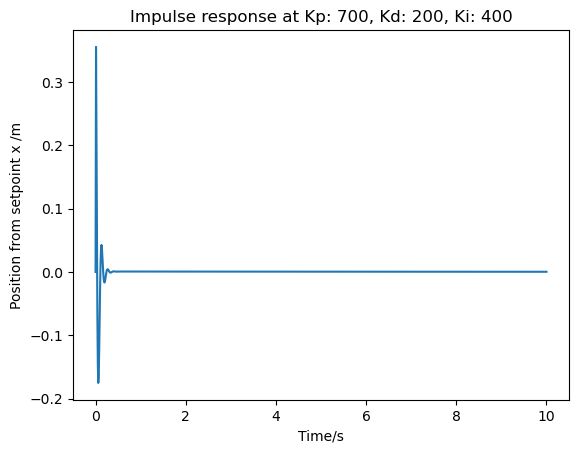

Max: 0.355 m 
Min: -0.175 m
Maximum overshoot: 36.493%



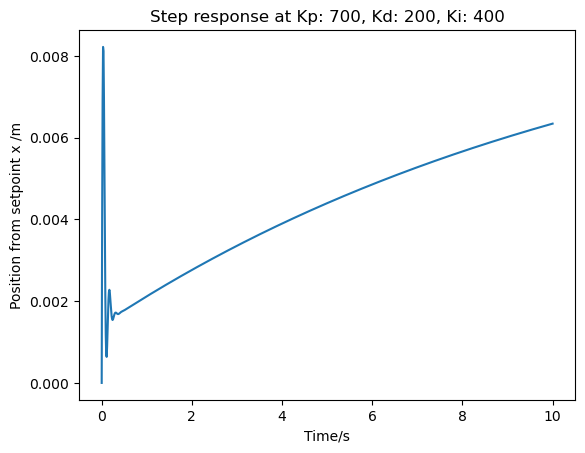

Max: 0.0082 m 
Min: 0.0000 m
Maximum overshoot: 1.7119%


x1e: 0.490 m, x3e: 0.696 A


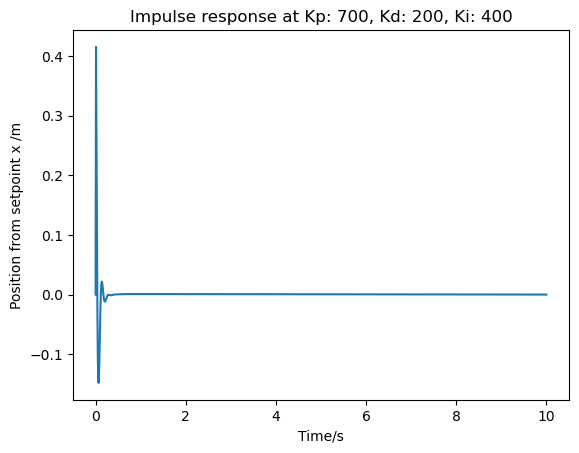

Max: 0.415 m 
Min: -0.148 m
Maximum overshoot: 30.161%



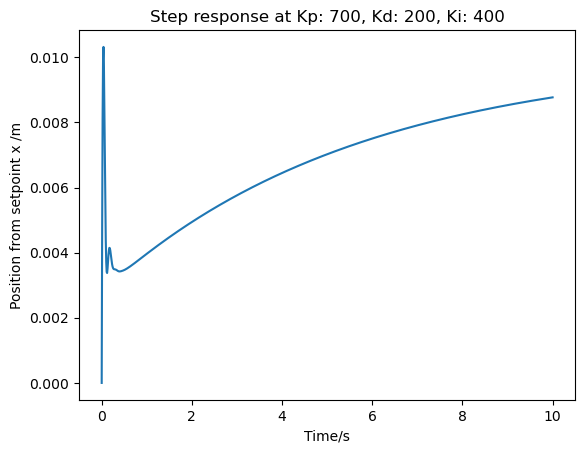

Max: 0.0103 m 
Min: 0.0000 m
Maximum overshoot: 2.1055%


x1e: 0.500 m, x3e: 0.699 A


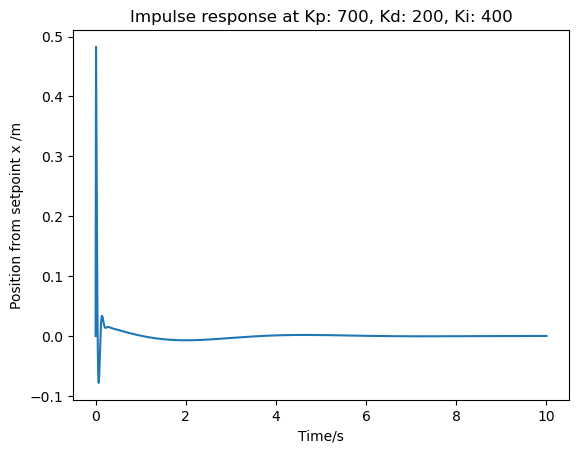

Max: 0.483 m 
Min: -0.078 m
Maximum overshoot: 15.658%



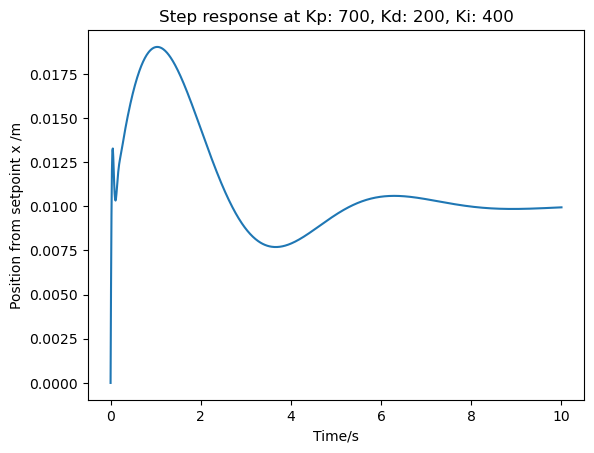

Max: 0.0190 m 
Min: 0.0000 m
Maximum overshoot: 3.8045%


x1e: 0.510 m, x3e: 0.693 A
Unstable, skipping impulse and step responses.

x1e: 0.520 m, x3e: 0.678 A
Unstable, skipping impulse and step responses.

x1e: 0.530 m, x3e: 0.657 A
Unstable, skipping impulse and step responses.



In [ ]:
for i in [0.48, 0.49, 0.5, 0.51, 0.52, 0.53]:
    x_1e = i
    x_3e = (delta - x_1e)*sqrt( (k*(x_1e-d) - m*g*sin(phi)) / c_val)

    print(f"x1e: {x_1e:.3f} m, x3e: {x_3e:.3f} A")


    a_3 = (5/(7*m)) * (2*c_val*x_3e)/((delta - x_1e)**2) #x3
    a_2 = (5/(7*m))*(-b) #x2
    a_1 = (5/(7*m)) * ( (2*c_val*(x_3e**2) ) / ( (delta - x_1e)**3 )  -k) #x1

    b_1 = 1/ (L0 + L1*exp(-alpha*(delta - x_1e)))
    b_2 = -R/ (L0 + L1*exp(-alpha*(delta - x_1e)))

    Gm = a_3/(s**2 - a_2*s - a_1)
    Ge = b_1/(s - b_2)
    Gs = (1)/((tau*s)+1)

    Gme = Gm*Ge

    Kp = 700
    Kd = 200
    Ki = 400
    Gc = Kp + Ki/s + Kd*s

    G_closed_loop = ctrl.feedback(Gme*Gc, Gs)

    poles = ctrl.poles(G_closed_loop)
    
    if not all(pole.real < 0 for pole in poles):
        print("Unstable, skipping impulse and step responses.\n")

    else:
        #Impulse response
        time,xs = ctrl.impulse_response(Gload, timepts=np.linspace(0, 10, 1000))
        xs_scaled = xs*0.01
        plt.plot(time, xs_scaled)
        plt.title(f"Impulse response at Kp: {Kp}, Kd: {Kd}, Ki: {Ki}")
        plt.xlabel("Time/s")
        plt.ylabel("Position from setpoint x /m")
        plt.show()

        impulse_response_max_value = max(xs_scaled)
        impulse_response_min_value = min(xs_scaled)
        impulse_response_max_overshoot = abs(impulse_response_min_value )

        print(f"Max: {impulse_response_max_value:.3f} m \nMin: {impulse_response_min_value:.3f} m")
        print(f"Maximum overshoot: {(impulse_response_max_overshoot / x_1e)*100:.3f}%\n")

        #Step response
        time,xs = ctrl.step_response(Gload, timepts=np.linspace(0, 10, 1000))
        xs_scaled = xs*0.01
        plt.plot(time, xs_scaled)
        plt.title(f"Step response at Kp: {Kp}, Kd: {Kd}, Ki: {Ki}")
        plt.xlabel("Time/s")
        plt.ylabel("Position from setpoint x /m")
        plt.show()

        step_response_max_value = max(xs_scaled)
        step_response_min_value = min(xs_scaled)
        step_response_max_overshoot = max( abs(step_response_max_value) , abs(step_response_min_value) )

        print(f"Max: {step_response_max_value:.4f} m \nMin: {step_response_min_value:.4f} m")
        print(f"Maximum overshoot: {(step_response_max_overshoot / x_1e)*100:.4f}%\n\n")
